In [1]:
from trim.model import *
from trim.computation import *
from trim.entresults import *
import trim.infocore_modified as ifc
from trim.analysis_modified import visualisation_conditioned,decision_tree
import matplotlib.pyplot as plt
from sklearn import metrics
import re
import pandas as pd
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

# Figure 3

In [5]:
#Initialising the network
n_nodes = 10
edge_list = [[1,2],[1, 4],[1,6],[3,6],[3,8],[3,10],[4,9],[5,7],[5,8],[6,7],[8,9],[9,10]]
n_edges = len(edge_list)
B = create_node_edge_incidence_matrix(edge_list)
K = np.array([[0, 0, 0, 0, 0,0,0,0,0,0],[0,0,-1,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,1,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,1,0,0,0],[0,0,0,-1,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,1,0,0]])

#Initialising and running the model
model = NDwTIs(
    B=B, K=K, w_pos=8, w_neg=0.5,
    threshold=1e-3, alpha=0.05, noise_std=1*(1e-2),
    x_init=np.zeros(n_nodes), dt=1e-2, t_max=4000.)
timeseries = model.run()
timeseries = np.array(timeseries)
timeseries = timeseries[:,-200000::5]

Sigma, T, Tn 0.3578123250497165 1.4123805823074793 0.4565189847920479
Sigma_mean_null 0.11745970597454286
T_mean_null 0.7055316714084503
Tn_mean_null 0.5504393648406791
P 0.5 P_T 0.5 P_Tn 1.0
Theta 908.4431993827161 Theta_T 35.84942165274903 Theta_Tn 146.09878672074007


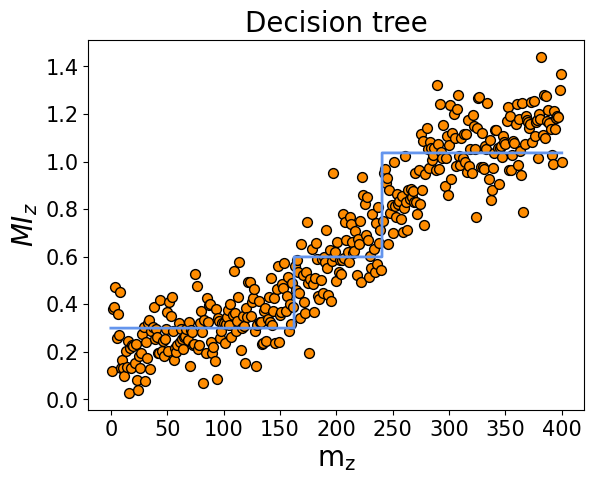

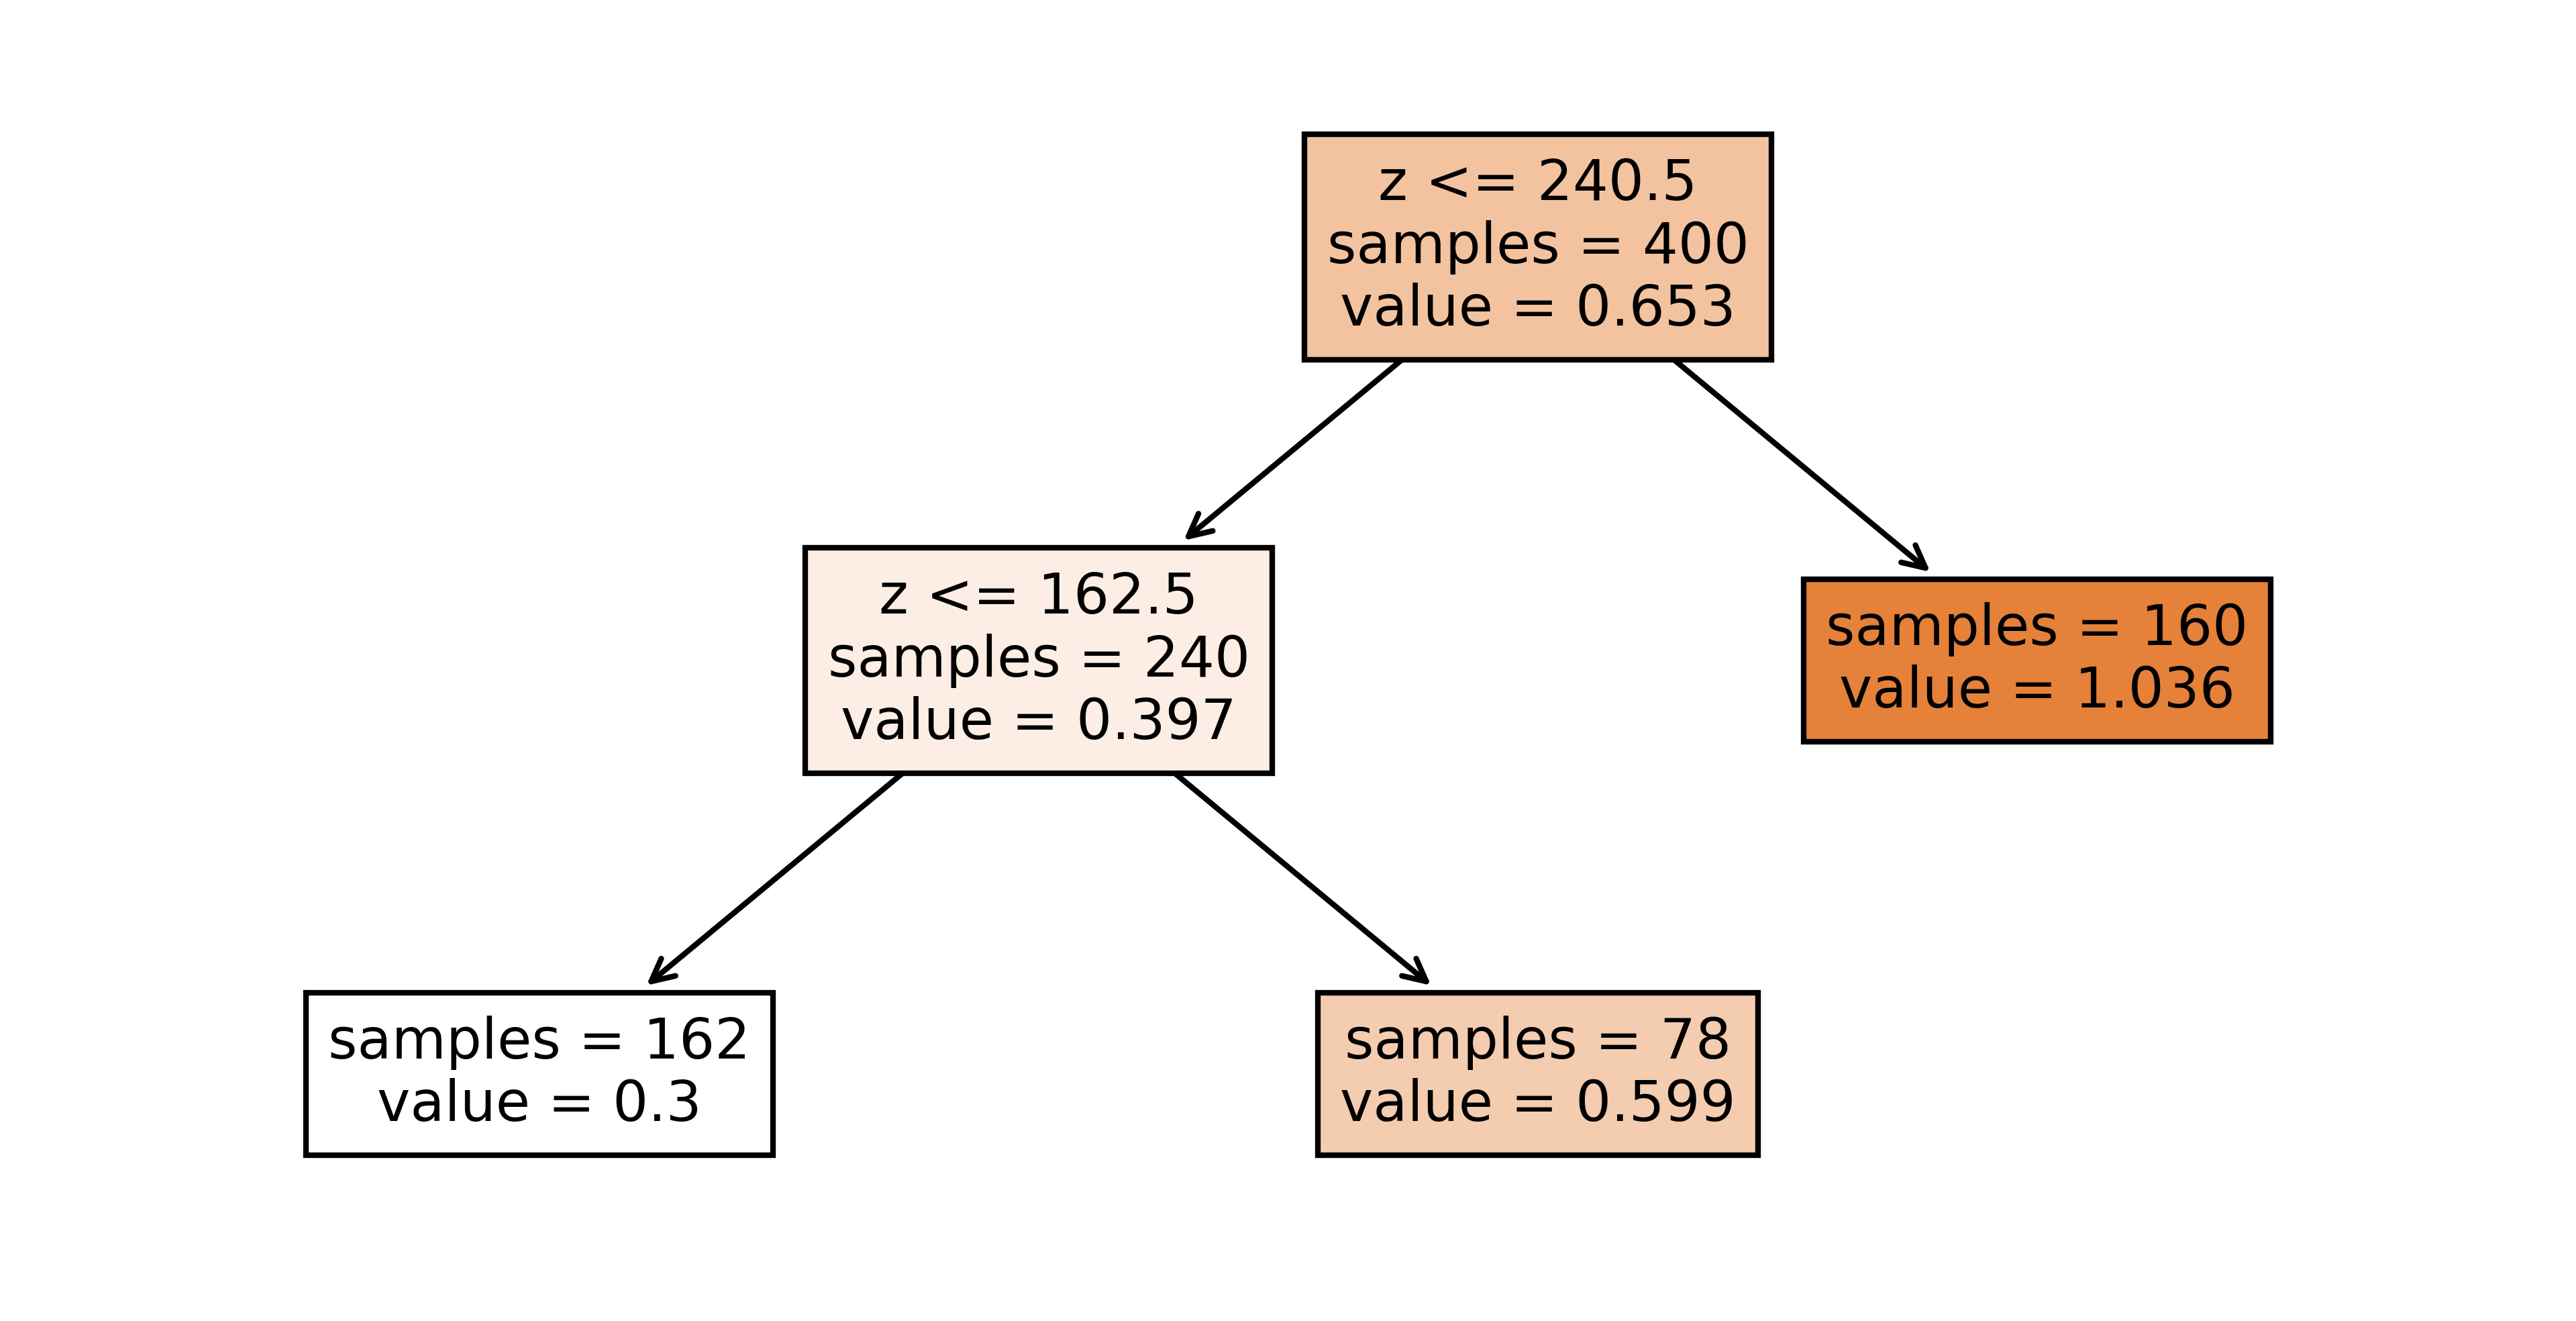

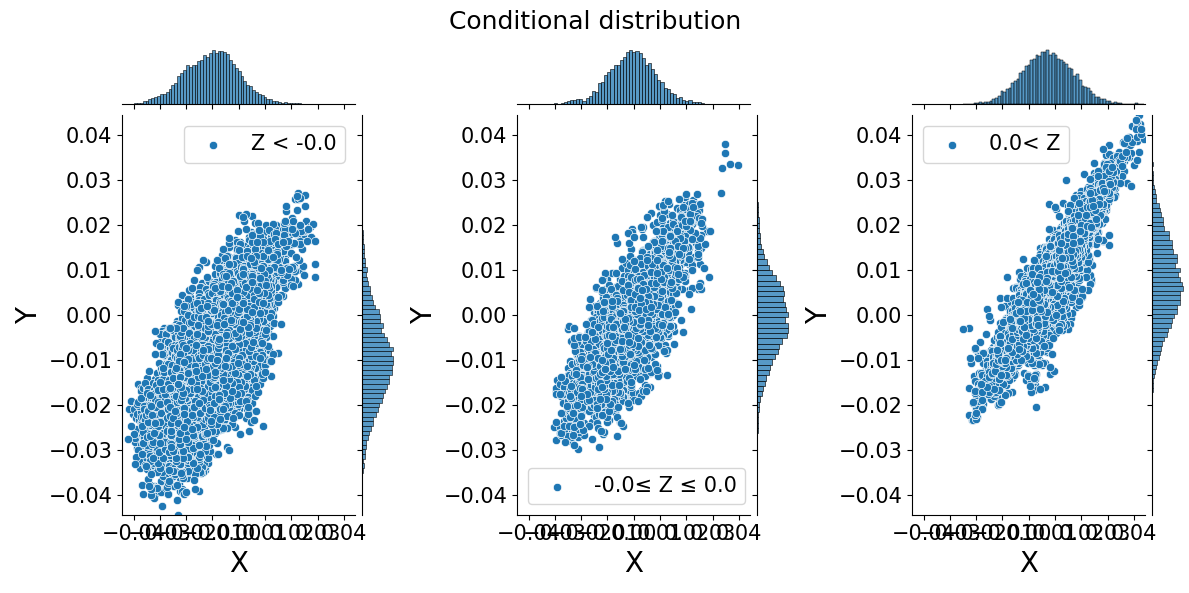

In [6]:
#TRIM algorithm for triple 4,9,5
tlen = 40000
num = round(tlen/100)
nrunmax = 2
I=[4,9,5]
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, False, True)
x = np.arange(1, num+1)
#Producing the figures
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True)
I = np.array(I)-1
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])

# Figure 4

Sigma, T, Tn 0.09881292678443285 0.5374998322392512 0.39262407654869236
Sigma_mean_null 0.10407546552764416
T_mean_null 0.5743924121668171
Tn_mean_null 0.5343210889952206
P 1.0 P_T 1.0 P_Tn 1.0
Theta 1.391300853928886 Theta_T 1.200128575737021 Theta_Tn 8.066112758872745


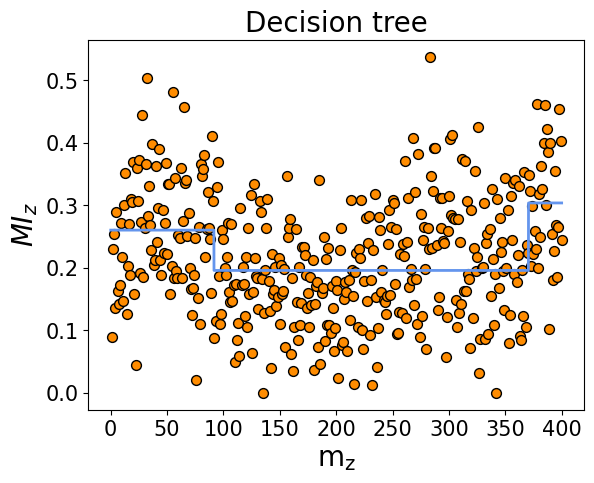

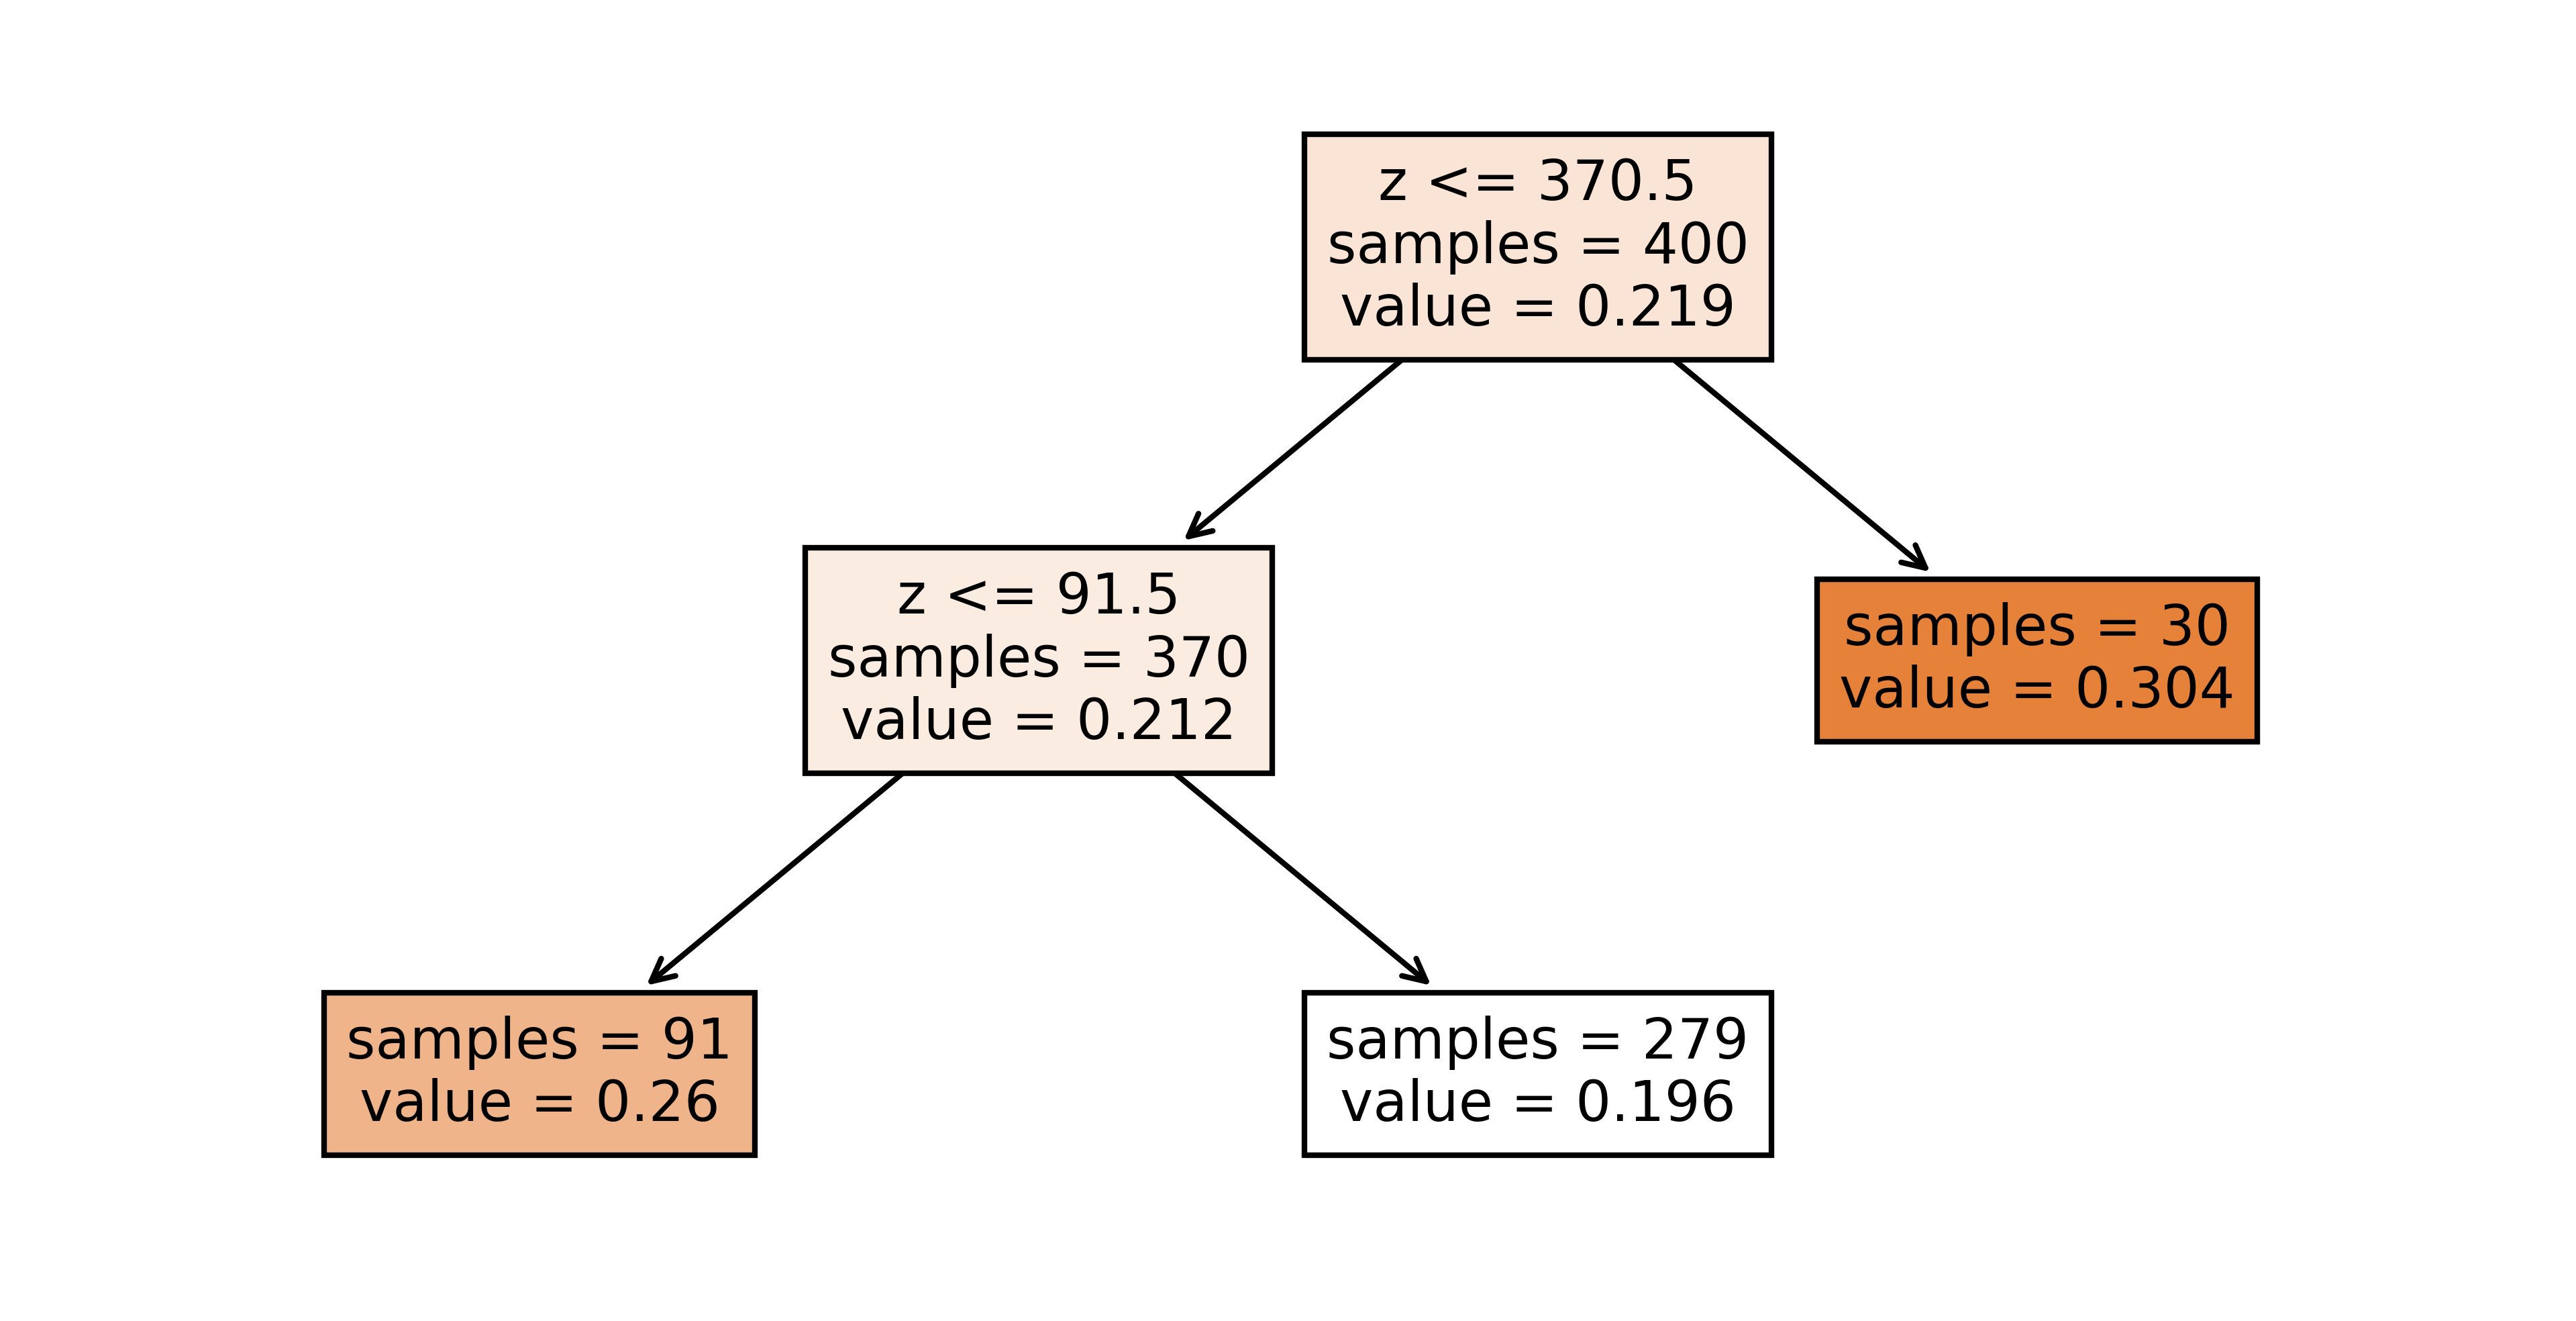

In [8]:
#TRIM algorithm for triple 1,2,6
tlen = 40000
num = round(tlen/100)
nrunmax = 2
I=[1,2,6]
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, False, True)
x = np.arange(1, num+1)
#Producing the figures
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True)

# Figure 5 

In [2]:
#Processing and formatting the results of the analysis of the small (N=10) network
edges2 = edge_processing(['EdgeT/edgeT12.txt','EdgeT/edgeT14.txt','EdgeT/edgeT16.txt','EdgeT/edgeT36.txt',
                         'EdgeT/edgeT38.txt','EdgeT/edgeT310.txt','EdgeT/edgeT49.txt','EdgeT/edgeT57.txt',
                         'EdgeT/edgeT58.txt','EdgeT/edgeT67.txt','EdgeT/edgeT89.txt','EdgeT/edgeT910.txt'])
edge_ROC = pd.read_csv('ROC005-5.csv')
edge_ROC_2 = pd.read_csv('ROC005-1.csv')

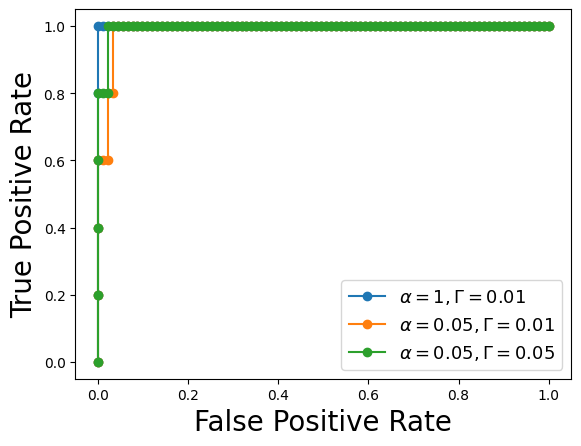

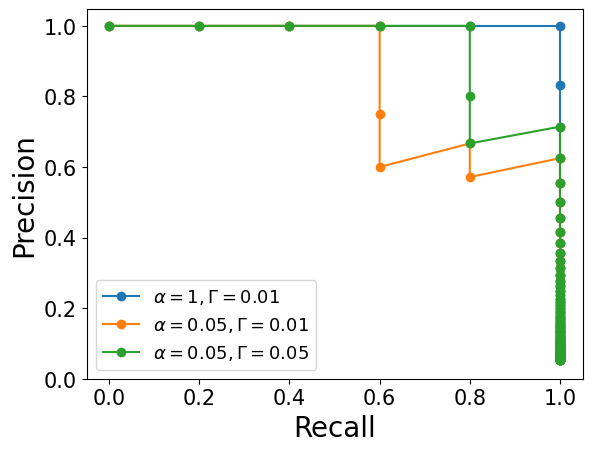

In [3]:
#Plotting the ROC curve
y = np.array([0,0,0,0,0,0,0,0,
              0,0,1,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,1,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,1,0,
              0,0,0,0,1,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,0,
              0,0,0,0,0,0,0,1])
scores2 = np.ndarray.flatten(edges2[:,:,1])
scores_ROC = edge_ROC['Theta_Sigma'].tolist()
scores_ROC_2 = edge_ROC_2['Theta_Sigma'].tolist()
fpr2, tpr2, thresholds = metrics.roc_curve(y, scores2,drop_intermediate=False)
fpr_roc,tpr_roc, thresholds = metrics.roc_curve(y,scores_ROC,drop_intermediate=False)
fpr_roc2,tpr_roc2, thresholds = metrics.roc_curve(y,scores_ROC_2,drop_intermediate=False)
plt.figure()
plt.plot(fpr2,tpr2,'o-',label=r'$\alpha = 1, \Gamma = 0.01$')
plt.plot(fpr_roc2,tpr_roc2,'o-',label=r'$\alpha = 0.05, \Gamma = 0.01$')
plt.plot(fpr_roc,tpr_roc,'o-',label=r'$\alpha = 0.05, \Gamma = 0.05$')
plt.legend(fontsize=13)
plt.ylabel('True Positive Rate',fontsize=20)
plt.xlabel('False Positive Rate',fontsize=20)
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
#plt.savefig('ROC-curve.png',dpi=600,bbox_inches="tight")

f1, t1, thresholds = metrics.precision_recall_curve(y, scores2)
froc, troc, thresholds = metrics.precision_recall_curve(y,scores_ROC)
froc2,troc2, thresholds = metrics.precision_recall_curve(y,scores_ROC_2)
plt.figure()
plt.plot(t1,f1,'o-',label=r'$\alpha = 1, \Gamma = 0.01$')
plt.plot(troc2,froc2,'o-',label=r'$\alpha = 0.05, \Gamma = 0.01$')
plt.plot(troc,froc,'o-',label=r'$\alpha = 0.05, \Gamma = 0.05$')
plt.legend(fontsize=13)
plt.yticks(np.arange(0, 1.2, step=0.2))
plt.ylabel('Precision',fontsize=20)
plt.xlabel('Recall',fontsize=20)
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
#plt.savefig('PR-curve.png',dpi=600,bbox_inches="tight")

# Figure 6

<Figure size 640x480 with 0 Axes>

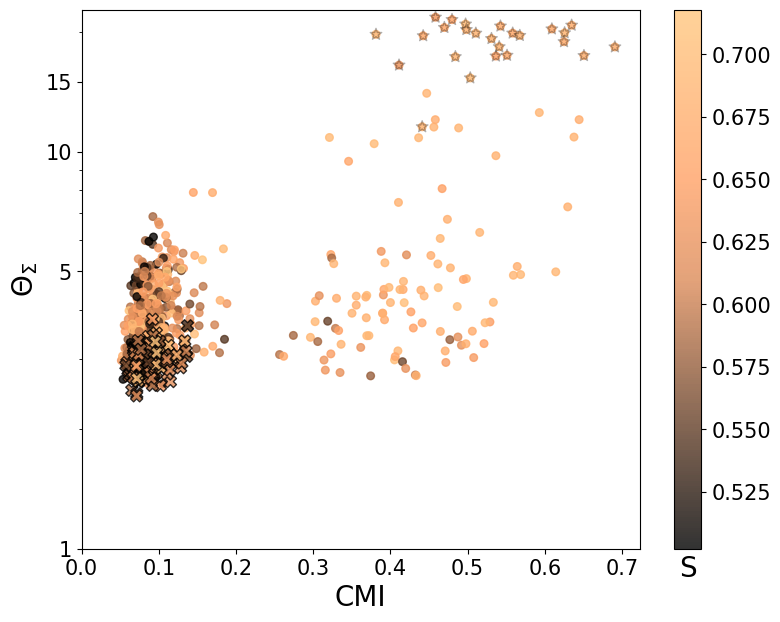

In [2]:
synth_trip_S = pd.read_csv('Merge_data/ran_t_S_norm.csv')
synth_trip_S = synth_trip_S.dropna()
synth_cr_S = pd.read_csv('Merge_data/ran_cr_S_norm.csv')
G = nx.read_gml('ran_100_t_matrices/network_100_t',destringizer=int)
K = np.load('ran_100_t_matrices/Kmat_100_t.npy')
Elist=nx.edges(G)
Elist=np.array(Elist)
Elist = Elist + 1
Elist = Elist.tolist()
x1 = np.where(K==-1)
x2 = np.where(K==1)
y1 = [[float(Elist[x1[0][i]][0]),float(Elist[x1[0][i]][1]),float(x1[1][i]+1)] for i in range(len(x1[0]))]
y2 = [[float(Elist[x2[0][i]][0]),float(Elist[x2[0][i]][1]),float(x2[1][i]+1)] for i in range(len(x2[0]))]
ran_true = pd.DataFrame()
for i in y1+y2:
    test = synth_trip_S[synth_trip_S['node1'] == i[0]]
    test = test[test['node2']==i[1]]
    test = test[test['reg']==i[2]]
    ran_true = pd.concat([ran_true, test])

plt.figure()
MI_MIC_merge(synth_trip_S,ran_true,synth_cr_S, key = 'S', display = 2.5, label = None) 

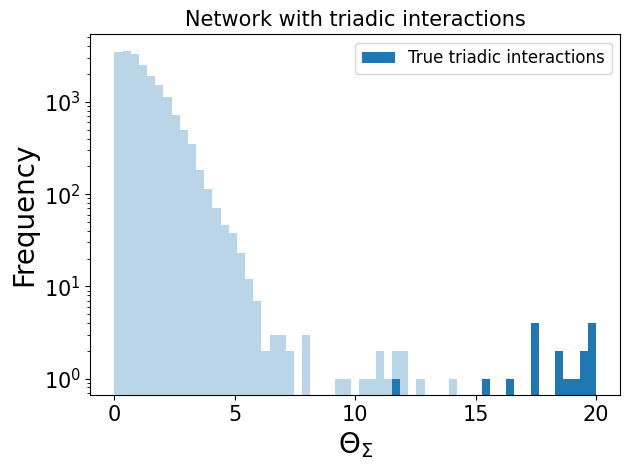

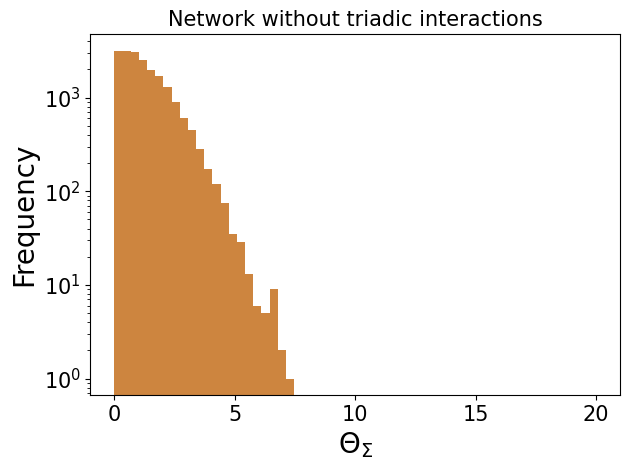

In [5]:
ran_t_0_alt = pd.read_csv('ran_100_t_P100_0.csv')
ran_t = pd.read_csv('ran_100_t_P100.csv')
plt.figure()
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
plt.hist(ran_t['Theta_Sigma'],bins=np.linspace(0,20,60),alpha=0.3,facecolor='tab:blue')
plt.hist(ran_true['Theta_Sigma'],bins=np.linspace(0,20,60),
         label='True triadic interactions',alpha=1,color='tab:blue')
plt.yscale('log')
plt.xlabel('$\Theta_\Sigma$', fontsize=20, color='black')
plt.ylabel('Frequency', fontsize=20, color='black')
plt.legend(fontsize=12)
plt.title('Network with triadic interactions',fontsize=15)
plt.tight_layout()

plt.figure()
plt.hist(ran_t_0_alt['Theta_Sigma'],bins=np.linspace(0,20,60),
         label='Network excluding triadic interactions',alpha=1,color='peru')
plt.yscale('log')
plt.xlabel('$\Theta_\Sigma$', fontsize=20, color='black')
plt.ylabel('Frequency', fontsize=20, color='black')
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
plt.title('Network without triadic interactions',fontsize=15)
plt.tight_layout()

# Figure 7

/var/folders/5f/66hpgr7n2y13tw1y000j2p5r0000gn/T/ipykernel_36328/1117192761.py:19: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which hasknown issues and is not actively maintained. Consider usingnx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  pos = graphviz_layout(T, prog="fdp")


Graph:


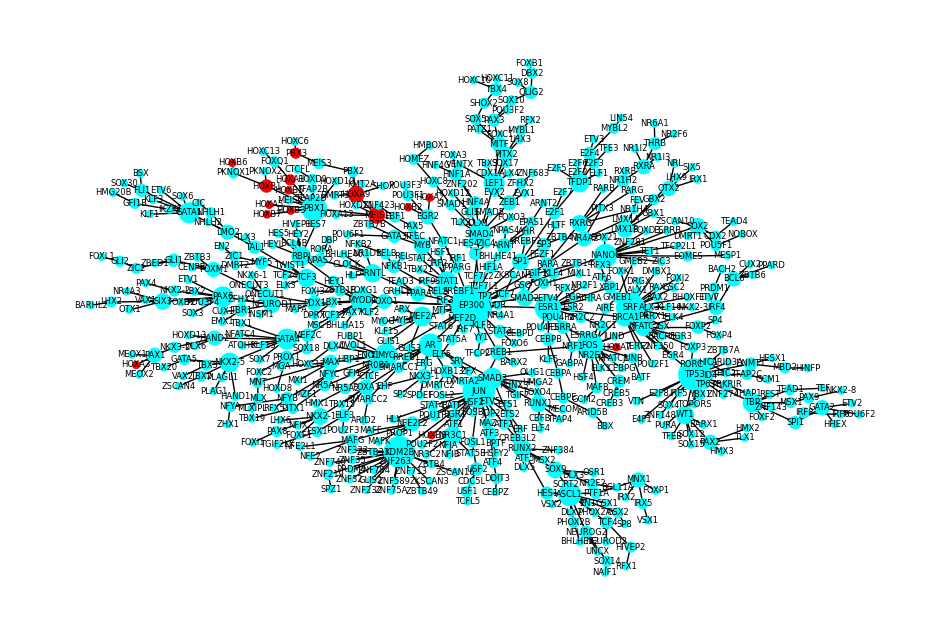

In [8]:
#Constructing the Maximal Spanning Tree from the PPI Edge Data
ppi = pd.read_csv('data/reduce_ppi.tsv', sep = '\t')
graph_ppi = nx.from_pandas_edgelist(ppi, source = '0', target = '1',edge_attr='2')
T = nx.maximum_spanning_tree(graph_ppi,weight = '2')
L = ['HOXA1','HOXA2','HOXA3','HOXA4','HOXA5','HOXA6','HOXA7','HOXA8','HOXA9','HOXB1','HOXB2','HOXB3','HOXB4','HOXB5','HOXB6','HOXB7','HOXB8','HOXB9','PBX3','MEIS1']
fig = plt.figure(figsize=(12,8))
Gcc = sorted(nx.connected_components(T), key=len, reverse=True)
G0 = T.subgraph(Gcc[0])
f = nx.Graph()
fedges = filter(lambda x: G0.degree()[x[0]] > 0 and G0.degree()[x[1]] > 0, G0.edges())
f.add_edges_from(fedges)
color_map=[]
NodeSize = []
for n in f.nodes:
    NodeSize.append(G0.degree(n)*25)
    if n in L:
        color_map.append('red')
    else:
        color_map.append('cyan')
pos = graphviz_layout(T, prog="fdp")
nx.draw(f,node_size=NodeSize,pos=pos,ax=fig.add_subplot(),node_color=color_map)
nx.draw_networkx_labels(f,pos=pos,font_size=6)
print('Graph:')

# Figure 8

0.2399152595790664


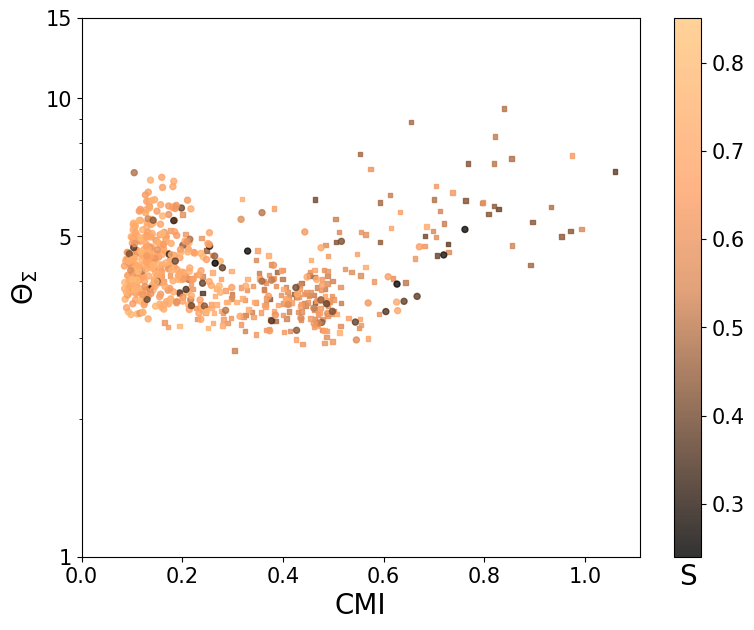

In [3]:
gene_alg = pd.read_csv('Merge_data/ran_tri_5_norm.csv')
CR = pd.read_csv('Merge_data/cr_tri_5_norm.csv')
bio_cr = pd.read_csv('Merge_data/cr_bio_5_norm.csv')
CR = pd.concat([CR,bio_cr])
gene_alg = gene_alg.dropna()
CR = CR.dropna()
Bio_out_S = pd.read_csv('Merge_data/ran_bio_5_norm_2.csv')
empty = CR[CR['reg']=='???']
MI_MIC_merge(Bio_out_S, gene_alg, empty, key = 'S', display = 4, label = None)

In [10]:
gene_expression = pd.read_csv('data/reduce_gene_expression.tsv', sep = '\t', index_col=0)

Sigma, T, Tn 0.3846935279042448 0.9251806630931907 0.6393281170241394
Sigma_mean_null 0.12673564182681848
T_mean_null 0.34532309345973
Tn_mean_null 0.2940605858797902
P 0.01 P_T 0.01 P_Tn 0.01
Theta 6.177299608714593 Theta_T 5.129598680684369 Theta_Tn 3.270152988589834


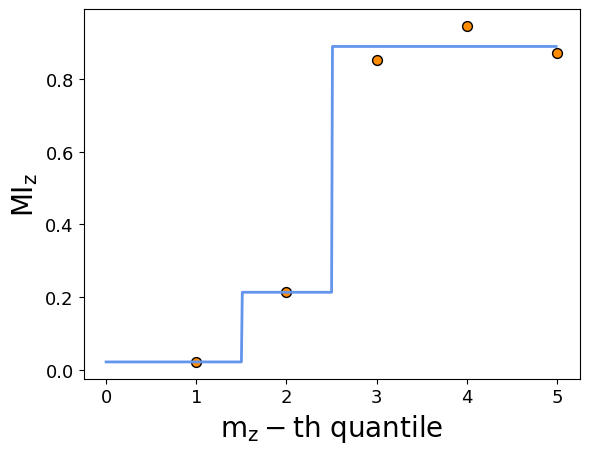

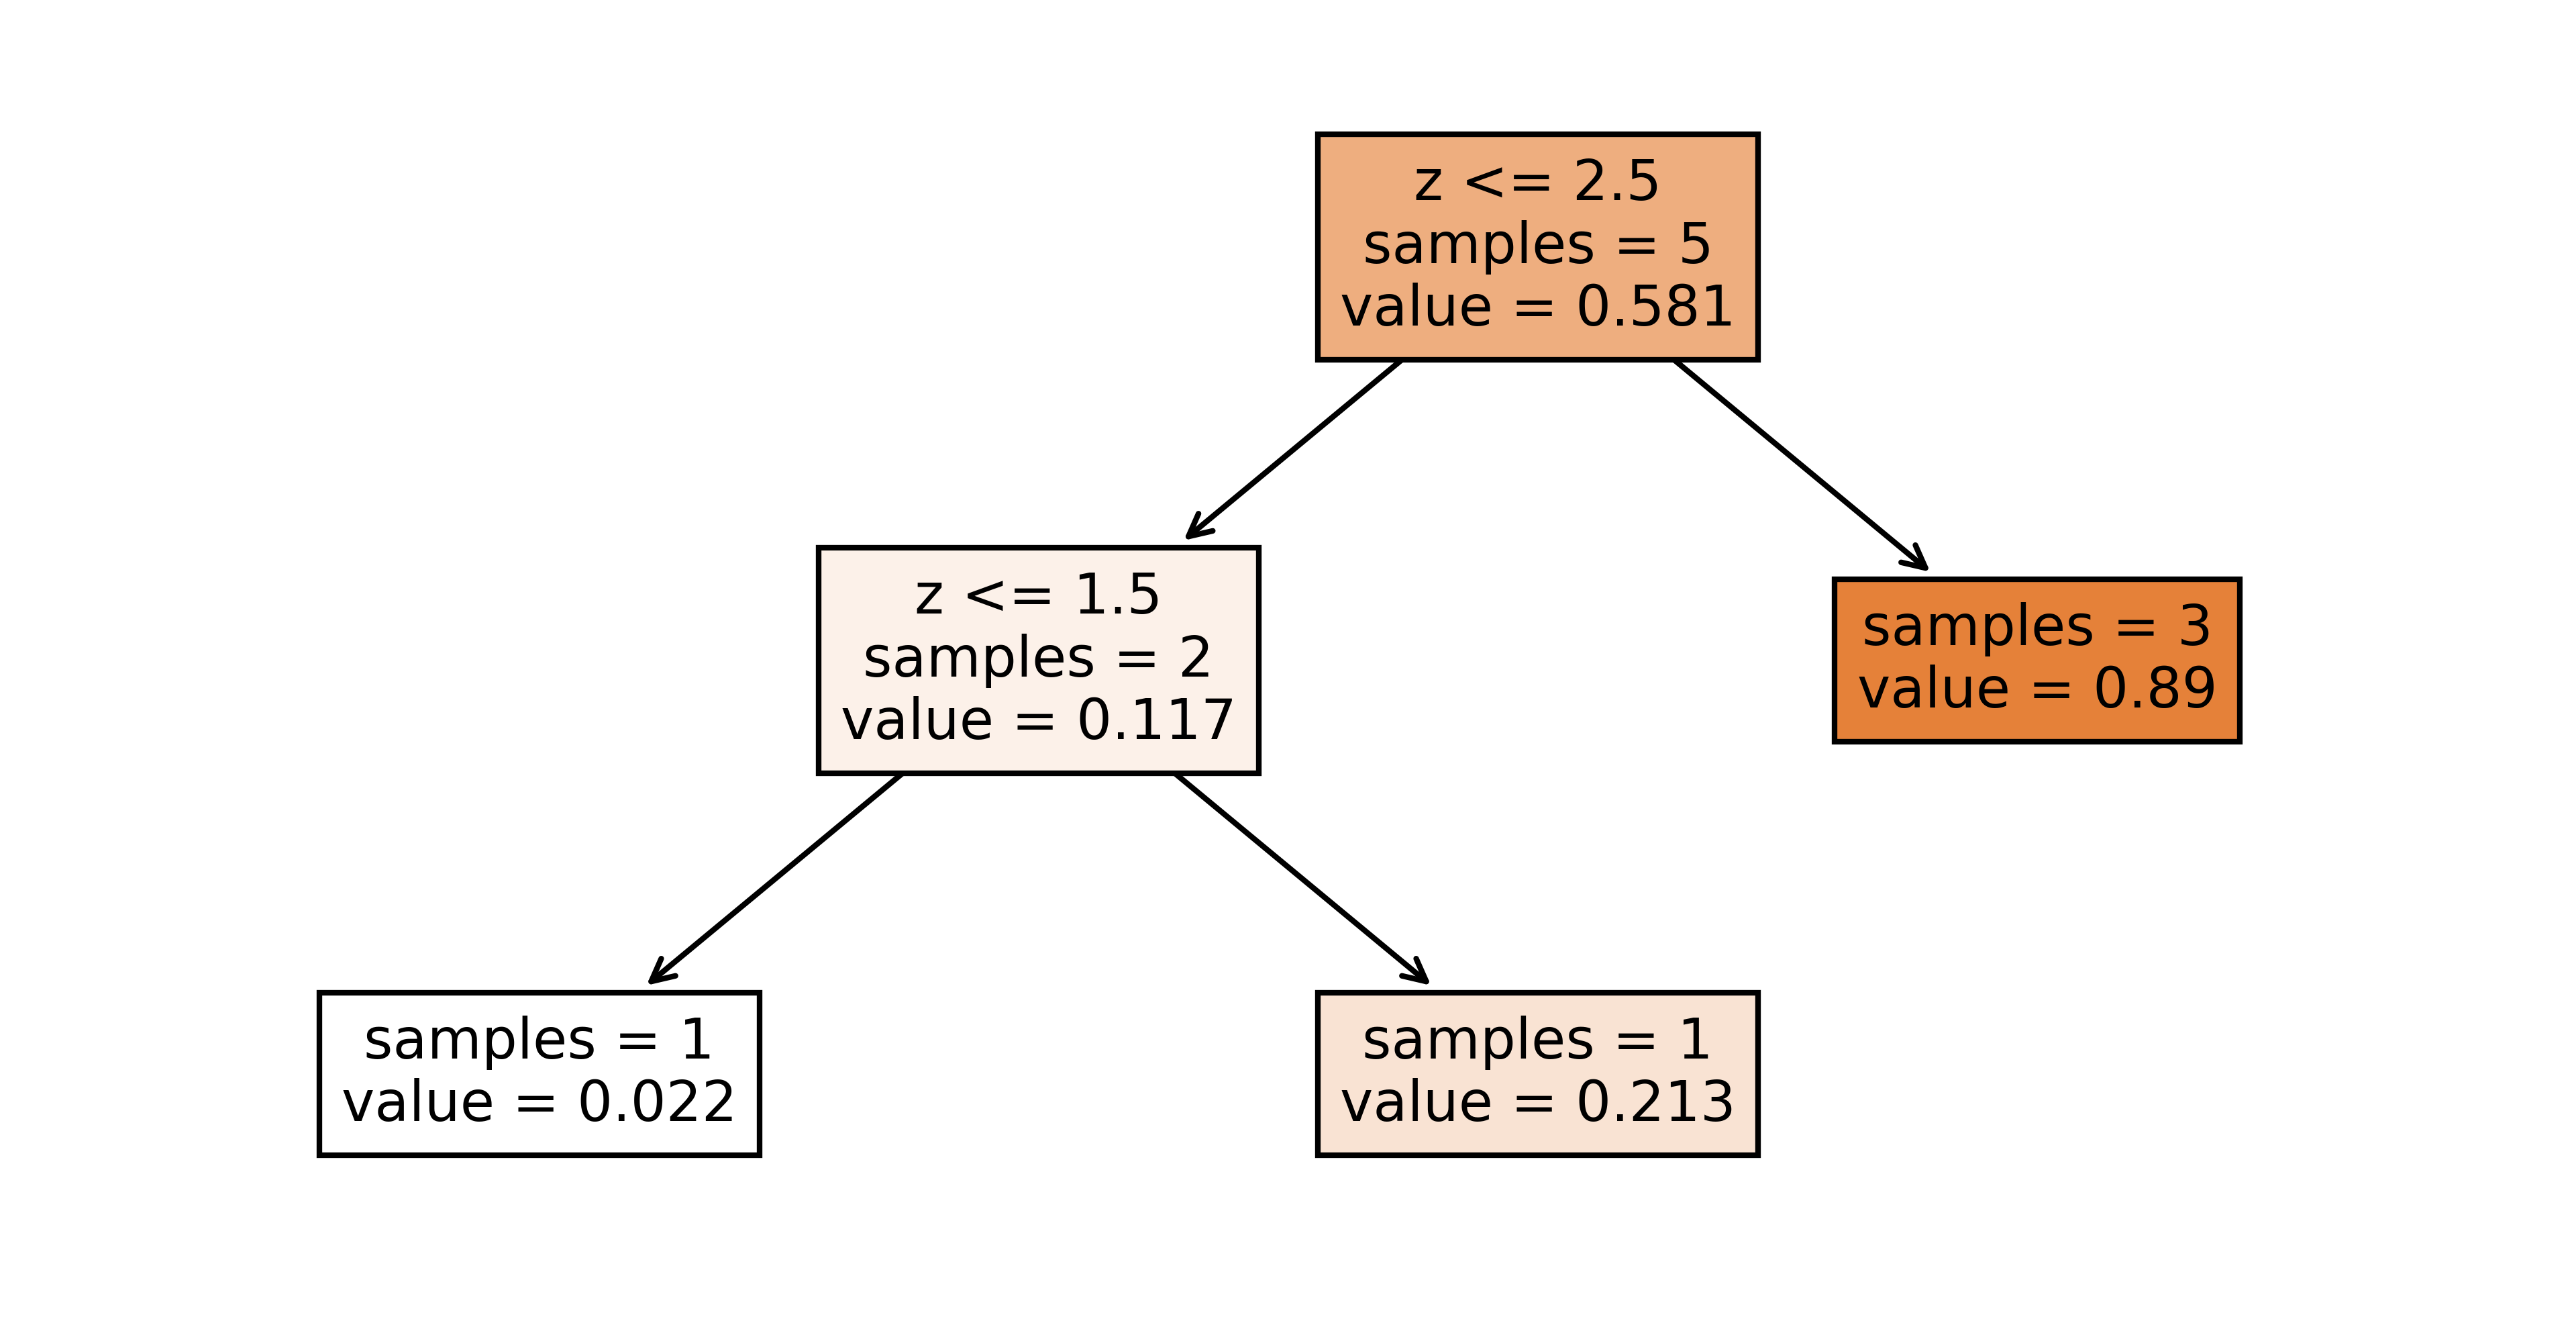

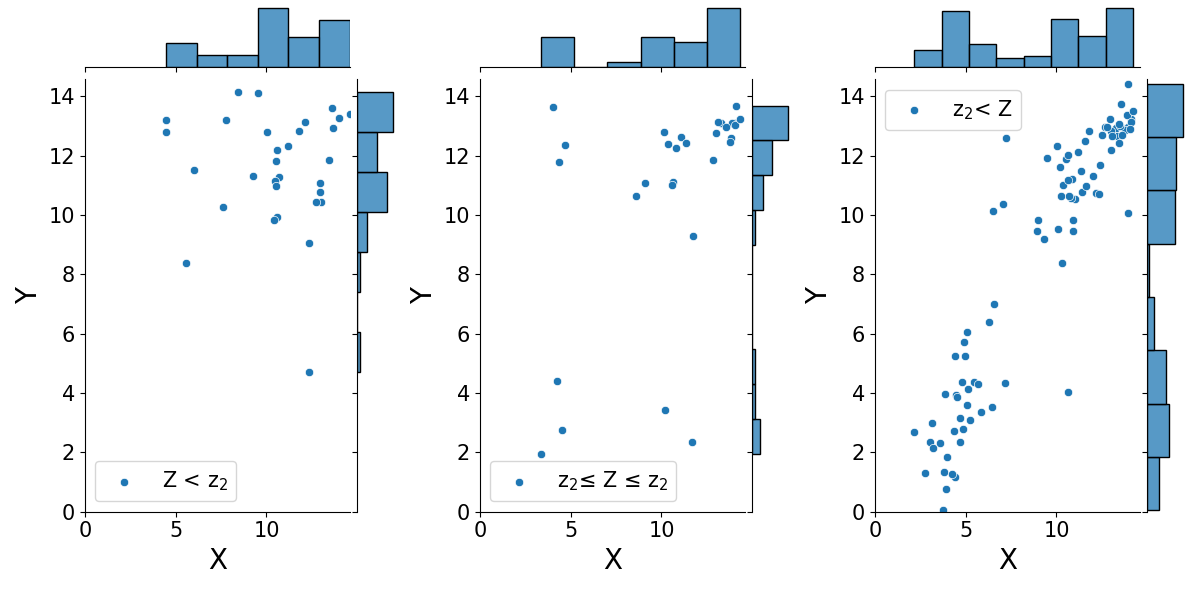

In [11]:
#getting Timeseries data for genes
name_X = 'HOXB3'
name_Y = 'MEIS1'
name_Z = 'GLIS3'

X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 100
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1, th2, c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True, name = 'd_tree_bio')
I = [0,1,2]
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])

Sigma, T, Tn 0.4407285194367151 1.0260321296350707 0.9351831637861043
Sigma_mean_null 0.13979367300666473
T_mean_null 0.3858888153263208
Tn_mean_null 0.32874704429994006
P 0.0001 P_T 0.0001 P_Tn 0.0003
Theta 5.943658410897534 Theta_T 4.474265251924143 Theta_Tn 4.459797733258061


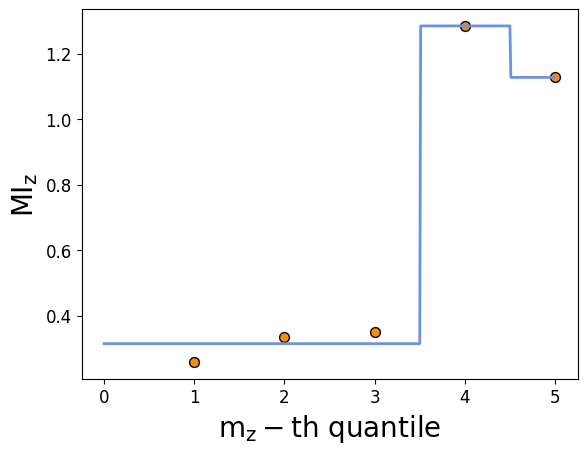

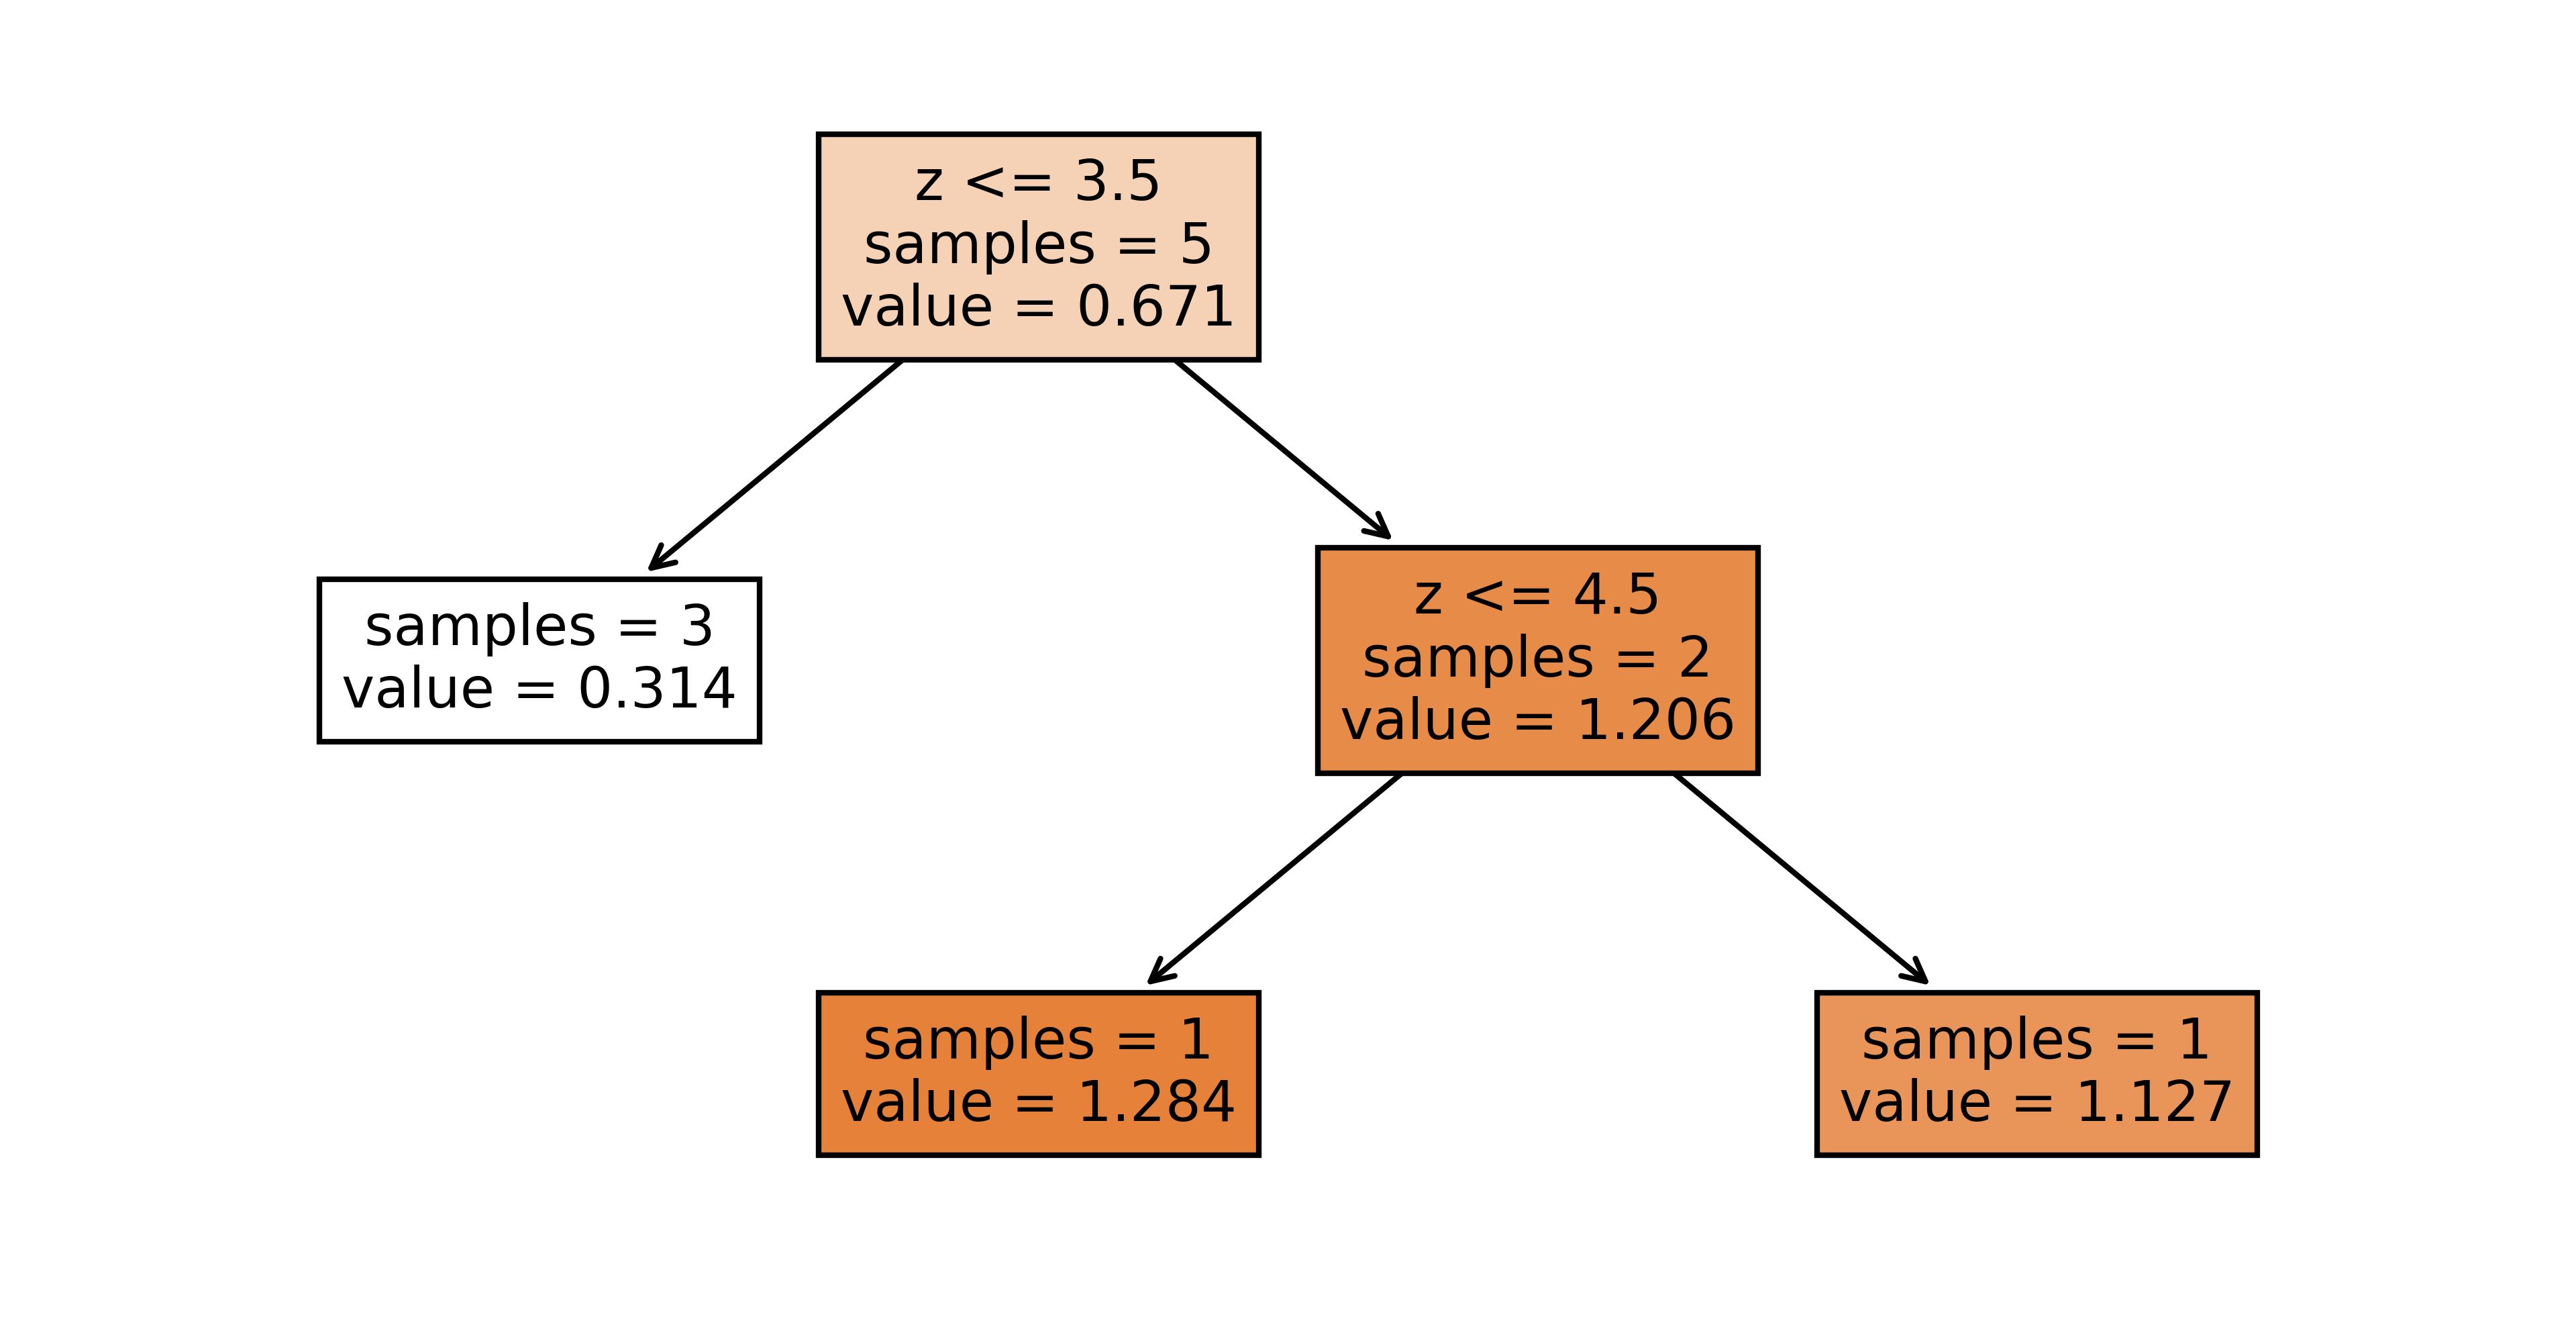

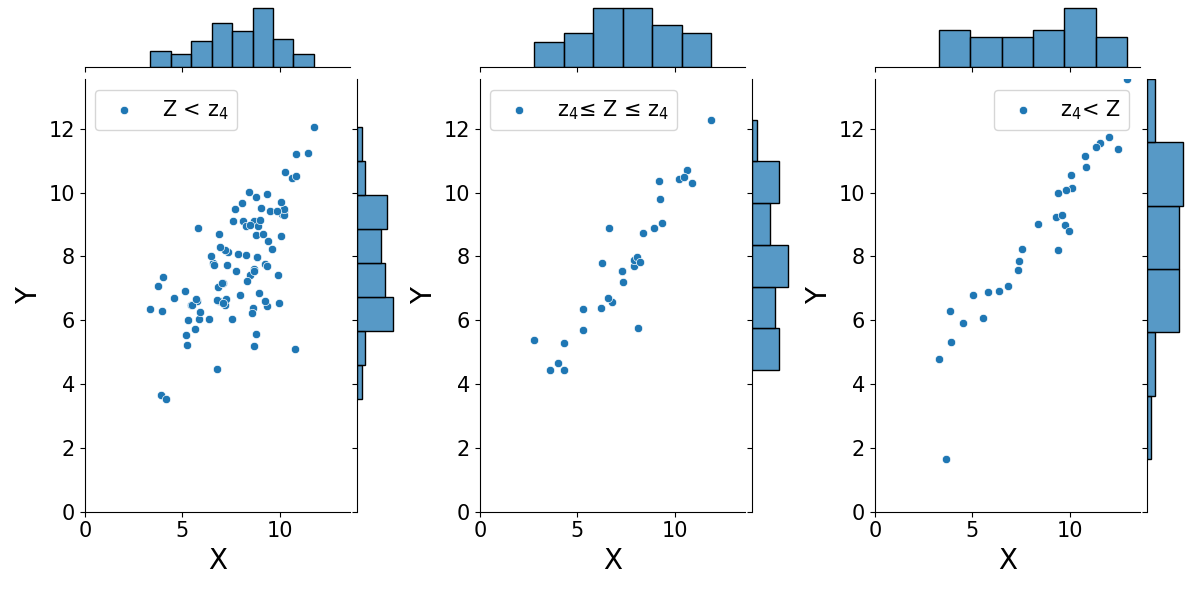

In [12]:
name_X = 'GATA1'
name_Y = 'KLF1'
name_Z = 'ETV1'

X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 10000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1, th2, c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True)
I = [0,1,2]
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])